# Re-process a single image
Pick one FITS file, run PyBDSF (with and without spurious removal), inspect every intermediate result inline, then write the outputs into the **same folder tree** used by `preprocess_bdsf_only.py`.

In [1]:
import bdsf
import os
import numpy as np
from pathlib import Path
from astropy.io import fits
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Configuration
Just set the **index** (e.g. `L0001`, `S0385`, `M1001`) — the notebook finds the FITS file and label automatically.

In [2]:
# ── CHANGE THIS ONLY ──
INDEX = "L0544"  # e.g. L0001, S0385, M1001

# ── Folder roots (same as preprocess_bdsf_only.py) ──
ROOT = "/path/to/rgc/rgc_dataset"
import glob as _glob
import re as _re

def find_fits_by_index(index):
    """Search all label folders under raw_fits/ for a file containing the given index."""
    raw_fits_root = os.path.join(ROOT, "raw_fits")
    for label_folder in sorted(os.listdir(raw_fits_root)):
        label_dir = os.path.join(raw_fits_root, label_folder)
        if not os.path.isdir(label_dir):
            continue
        for f in os.listdir(label_dir):
            if not f.endswith(".fits") or f.endswith(".pybdsf.log"):
                continue
            # Match index in filename: e.g. nat_L0001_... or sfrii_M0728_...
            match = _re.search(r'_(' + _re.escape(index) + r')_', f)
            if match:
                return label_folder, f
    return None, None

LABEL, FITS_FILENAME = find_fits_by_index(INDEX)
if LABEL is None:
    raise FileNotFoundError(f"No FITS file found for index '{INDEXM0952}' in {ROOT}/raw_fits/*/")

raw_fits_dir              = os.path.join(ROOT, "raw_fits",              LABEL)
no_spur_mask_fits_dir     = os.path.join(ROOT, "no_spurious_mask_fits", LABEL)
spur_mask_fits_dir        = os.path.join(ROOT, "spurious_mask_fits",    LABEL)
raw_png_dir               = os.path.join(ROOT, "raw_png",              LABEL)
no_spur_mask_png_dir      = os.path.join(ROOT, "no_spurious_mask_png", LABEL)
spur_mask_png_dir         = os.path.join(ROOT, "spurious_mask_png",    LABEL)
no_spur_masked_png_dir    = os.path.join(ROOT, "no_spurious_masked_png", LABEL)
spur_masked_png_dir       = os.path.join(ROOT, "spurious_masked_png",  LABEL)

FITS_PATH = os.path.join(raw_fits_dir, FITS_FILENAME)
STEM      = Path(FITS_FILENAME).stem

print(f"Index     : {INDEX}")
print(f"Label     : {LABEL}")
print(f"Filename  : {FITS_FILENAME}")
print(f"FITS path : {FITS_PATH}")
print(f"Stem      : {STEM}")

Index     : L0544
Label     : nat
Filename  : nat_L0544_073540.42+361918.5.fits
FITS path : /path/to/rgc/rgc_dataset/raw_fits/nat/nat_L0544_073540.42+361918.5.fits
Stem      : nat_L0544_073540.42+361918.5


In [3]:
# ── PyBDSF parameters (same as main script) ──
BDSF_PARAMS = dict(
    frequency       = 1.4e9,
    beam            = (5.4/3600, 5.4/3600, 0.0),
    thresh_isl      = 3,
    thresh_pix      = 5,
    rms_box         = (25, 8),
    atrous_do       = True,
    rms_map         = False,
    mean_map        = 'zero',
    flag_maxsize_bm = 50,
)
NEIGHBOR_PIXEL_DIST = 10

## 2. Helper functions

In [4]:
def fits_to_array(fits_path):
    """Read a FITS file and return a 2-D float array (NaN → min)."""
    data   = fits.getdata(fits_path)
    header = fits.getheader(fits_path)
    w, h   = header["NAXIS1"], header["NAXIS2"]
    arr    = np.reshape(data, (h, w)).astype(float)
    arr[np.isnan(arr)] = np.nanmin(arr)
    return arr


def array_to_uint8(arr):
    """Normalize a 2-D array to 0-255 uint8."""
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    if hi - lo == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - lo) / (hi - lo) * 255).astype(np.uint8)

def show_images(images, titles, figsize=(16, 4)):
    """Display a row of images with titles."""
    n = len(images)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for ax, img, title in zip(axs, images, titles):
        ax.imshow(img, cmap='gray', origin='lower')
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 3. Show the raw FITS image

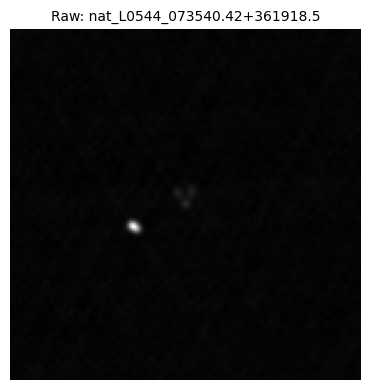

In [5]:
raw_arr = fits_to_array(FITS_PATH)
show_images([array_to_uint8(raw_arr)], [f"Raw: {STEM}"])

## 4. Run PyBDSF (source detection)

In [6]:
img = bdsf.process_image(FITS_PATH, **BDSF_PARAMS)
print(f"Islands found: {len(img.islands)}")
for isl in img.islands:
    print(f"  Island {isl.island_id}: bbox {isl.bbox}")

--> Opened '/path/to/rgc/rgc_dataset/raw_fits/nat/nat_L0544_073540.42+361918.5.fits'
Image size .............................. : (150, 150) pixels
Number of channels ...................... : 1
Number of Stokes parameters ............. : 1
 [astropy.io.fits.verify]
Beam shape (major, minor, pos angle) .... : (1.50000e-03, 1.50000e-03, 0.0) degrees
Frequency of image ...................... : 1400.000 MHz
Number of blank pixels .................. : 0 (0.0%)
Flux from sum of (non-blank) pixels ..... : 0.042 Jy
--> Calculating background rms and mean images
--> Using constant background rms
--> Using constant background mean
Value of background rms ................. : 1.81e-04 Jy/beam
Value of background mean ................ : 0.0 Jy/beam
--> Expected 5-sigma-clipped false detection rate < fdr_ratio
--> Using sigma-clipping ('hard') thresholding
Minimum number of pixels per island ..... : 6
Number of islands found ................. : 2


Fitting islands with Gaussians .......... : [|] 0/2

stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


/Fitting islands with Gaussians .......... : [/] 1/2/Fitting islands with Gaussians .......... : [/] 1/2Fitting islands with Gaussians .......... : [] 2/2[-4G

stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
Total number of Gaussians fit to image .. : 5
Total flux density in model ............. : 0.064 Jy

--> Wavelet scale #1
--> Calculating background rms and mean images
--> Using constant background rms
--> Using constant background mean


...

--> Calculating background rms and mean images
--> Using constant background rms
--> Using constant background mean
Value of background rms ................. : 2.37e-05 Jy/beam
Value of background mean ................ : -1e-05 Jy/beam
Number of islands found ................. : 0


Checking islands for overlap ............ : [] 0/0
Checking islands for overlap ............ : [] 0/0


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device
--> Grouping Gaussians into sources
Number of sources formed from Gaussians   : 0
Total flux density in model on all scales : 0.064 Jy


stty: 'standard input': Inappropriate ioctl for device
--> Grouping Gaussians into sources
Number of sources formed from Gaussians   : 4


Islands found: 2
  Island 0: bbox [slice(48, 59, None), slice(60, 71, None)]
  Island 1: bbox [slice(68, 82, None), slice(71, 86, None)]


## 5a. Spurious mask (keep ALL islands)

--> Wrote file '/path/to/rgc/rgc_dataset/spurious_mask_fits/nat/nat_L0544_073540.42+361918.5_mask.fits'
Saved: /path/to/rgc/rgc_dataset/spurious_mask_fits/nat/nat_L0544_073540.42+361918.5_mask.fits


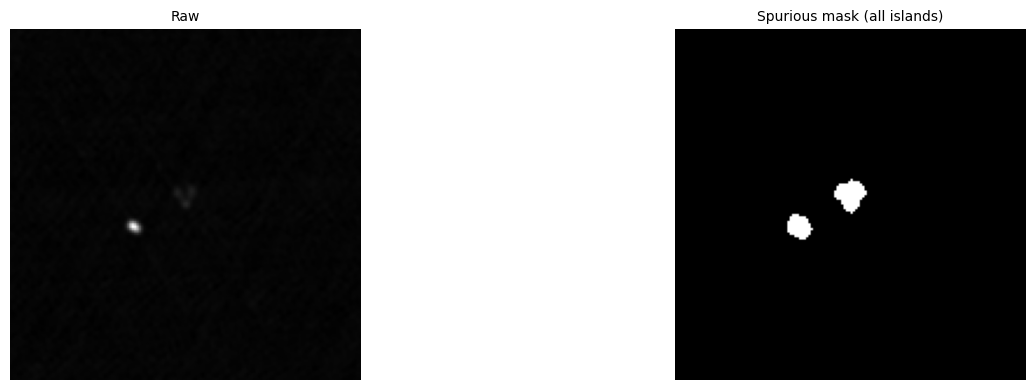

In [7]:
# Export spurious mask FITS (all islands)
Path(spur_mask_fits_dir).mkdir(parents=True, exist_ok=True)
spur_mask_fits_path = os.path.join(spur_mask_fits_dir, STEM + "_mask.fits")
img.export_image(
    img_type="island_mask",
    outfile=spur_mask_fits_path,
    clobber=True,
    mask_dilation=1,
)
print(f"Saved: {spur_mask_fits_path}")

# Show it
spur_mask_arr = fits_to_array(spur_mask_fits_path)
show_images(
    [array_to_uint8(raw_arr), array_to_uint8(spur_mask_arr)],
    ["Raw", "Spurious mask (all islands)"]
)

## 5b. No-spurious mask (central island + neighbors only)

In [8]:
# ── Find central island and its neighbors ──
island_positions = []
for isl in img.islands:
    island_id  = getattr(isl, "island_id", None)
    mask_active = isl.mask_active
    y_slice, x_slice = isl.bbox
    if mask_active.shape == img.ch0_arr.shape:
        mask_active = mask_active[y_slice, x_slice]
    coords = np.argwhere(~np.asarray(mask_active, dtype=bool))
    if coords.size == 0:
        continue
    y0, x0 = np.median(coords, axis=0)
    xpos, ypos = x0 + x_slice.start, y0 + y_slice.start
    island_positions.append((island_id, xpos, ypos))

image_center = np.array([img.ch0_arr.shape[1]/2, img.ch0_arr.shape[0]/2])

dist_to_center = [(iid, np.linalg.norm(np.array([x, y]) - image_center))
                  for iid, x, y in island_positions]
central_island_id = min(dist_to_center, key=lambda t: t[1])[0]
print(f"Central island: {central_island_id}")

# Neighbor graph
neighbor_dict = {}
for id1, x1, y1 in island_positions:
    neighbors = []
    for id2, x2, y2 in island_positions:
        if id1 != id2 and np.sqrt((x1-x2)**2 + (y1-y2)**2) <= NEIGHBOR_PIXEL_DIST:
            neighbors.append(id2)
    neighbor_dict[id1] = neighbors

central_neighbors = neighbor_dict.get(central_island_id, [])
keep_ids = {central_island_id} | set(central_neighbors)
print(f"Keeping islands: {sorted(keep_ids)}")
print(f"Removing islands: {sorted(set(i[0] for i in island_positions) - keep_ids)}")

Central island: 1
Keeping islands: [1]
Removing islands: [0]


--> Wrote file '/path/to/rgc/rgc_dataset/no_spurious_mask_fits/nat/nat_L0544_073540.42+361918.5_mask.fits'
Saved: /path/to/rgc/rgc_dataset/no_spurious_mask_fits/nat/nat_L0544_073540.42+361918.5_mask.fits


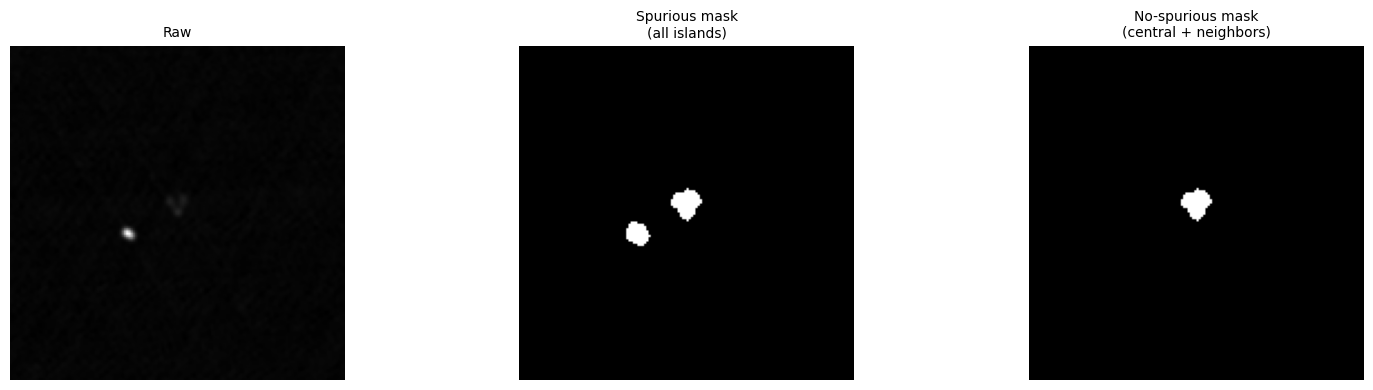

In [9]:
# ── Build and export no-spurious mask ──
original_islands = img.islands
img.islands = [isl for isl in original_islands
               if isl.island_id == central_island_id or isl.island_id in central_neighbors]

original_pyRank = img.pyrank.copy()
keep_islands = np.zeros_like(original_pyRank, dtype=bool)
for isl in img.islands:
    y_slice, x_slice = isl.bbox
    mask_active = isl.mask_active
    if mask_active.shape == img.ch0_arr.shape:
        mask_active = mask_active[y_slice, x_slice]
    keep_islands[y_slice, x_slice] |= (~mask_active).astype(bool)

img.pyrank = np.where(keep_islands, original_pyRank, -1).astype(original_pyRank.dtype)

Path(no_spur_mask_fits_dir).mkdir(parents=True, exist_ok=True)
no_spur_mask_fits_path = os.path.join(no_spur_mask_fits_dir, STEM + "_mask.fits")
try:
    img.export_image(
        img_type="island_mask",
        outfile=no_spur_mask_fits_path,
        clobber=True,
        mask_dilation=1,
    )
    print(f"Saved: {no_spur_mask_fits_path}")
finally:
    img.pyrank = original_pyRank
    img.islands = original_islands

# Show it
no_spur_mask_arr = fits_to_array(no_spur_mask_fits_path)
show_images(
    [array_to_uint8(raw_arr), array_to_uint8(spur_mask_arr), array_to_uint8(no_spur_mask_arr)],
    ["Raw", "Spurious mask\n(all islands)", "No-spurious mask\n(central + neighbors)"]
)

## 6. Convert to PNGs and apply masks

In [10]:
raw_uint8 = array_to_uint8(raw_arr)

# ── Raw PNG ──
Path(raw_png_dir).mkdir(parents=True, exist_ok=True)
raw_png_path = os.path.join(raw_png_dir, STEM + ".png")
Image.fromarray(raw_uint8, mode="L").save(raw_png_path)
print(f"Saved: {raw_png_path}")

# ── Spurious mask PNG ──
Path(spur_mask_png_dir).mkdir(parents=True, exist_ok=True)
spur_mask_uint8 = array_to_uint8(spur_mask_arr)
spur_mask_png_path = os.path.join(spur_mask_png_dir, STEM + "_mask.png")
Image.fromarray(spur_mask_uint8, mode="L").save(spur_mask_png_path)
print(f"Saved: {spur_mask_png_path}")

# ── No-spurious mask PNG ──
Path(no_spur_mask_png_dir).mkdir(parents=True, exist_ok=True)
no_spur_mask_uint8 = array_to_uint8(no_spur_mask_arr)
no_spur_mask_png_path = os.path.join(no_spur_mask_png_dir, STEM + "_mask.png")
Image.fromarray(no_spur_mask_uint8, mode="L").save(no_spur_mask_png_path)
print(f"Saved: {no_spur_mask_png_path}")

# ── Spurious masked PNG (raw × spurious mask) ──
Path(spur_masked_png_dir).mkdir(parents=True, exist_ok=True)
spur_binary = (spur_mask_uint8 > 0).astype(np.uint8)
spur_masked = np.where(spur_binary == 0, 0, raw_uint8)
spur_masked_png_path = os.path.join(spur_masked_png_dir, STEM + "_masked.png")
Image.fromarray(spur_masked.astype(np.uint8), mode="L").save(spur_masked_png_path)
print(f"Saved: {spur_masked_png_path}")

# ── No-spurious masked PNG (raw × no-spurious mask) ──
Path(no_spur_masked_png_dir).mkdir(parents=True, exist_ok=True)
no_spur_binary = (no_spur_mask_uint8 > 0).astype(np.uint8)
no_spur_masked = np.where(no_spur_binary == 0, 0, raw_uint8)
no_spur_masked_png_path = os.path.join(no_spur_masked_png_dir, STEM + "_masked.png")
Image.fromarray(no_spur_masked.astype(np.uint8), mode="L").save(no_spur_masked_png_path)
print(f"Saved: {no_spur_masked_png_path}")

Saved: /path/to/rgc/rgc_dataset/raw_png/nat/nat_L0544_073540.42+361918.5.png
Saved: /path/to/rgc/rgc_dataset/spurious_mask_png/nat/nat_L0544_073540.42+361918.5_mask.png
Saved: /path/to/rgc/rgc_dataset/no_spurious_mask_png/nat/nat_L0544_073540.42+361918.5_mask.png
Saved: /path/to/rgc/rgc_dataset/spurious_masked_png/nat/nat_L0544_073540.42+361918.5_masked.png
Saved: /path/to/rgc/rgc_dataset/no_spurious_masked_png/nat/nat_L0544_073540.42+361918.5_masked.png


## 7. Final comparison — all 5 outputs side by side

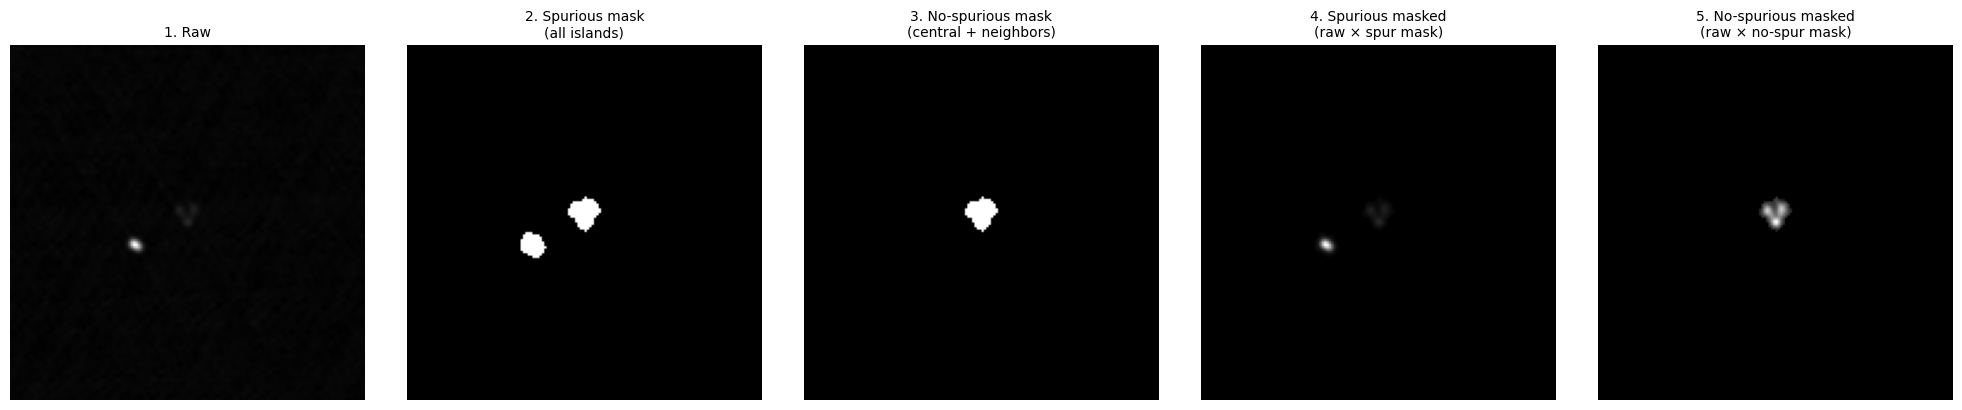


All outputs saved under: /path/to/rgc/rgc_dataset
Label folder: nat
Image stem:   nat_L0544_073540.42+361918.5


In [11]:
show_images(
    [raw_uint8, spur_mask_uint8, no_spur_mask_uint8, spur_masked, no_spur_masked],
    ["1. Raw",
     "2. Spurious mask\n(all islands)",
     "3. No-spurious mask\n(central + neighbors)",
     "4. Spurious masked\n(raw × spur mask)",
     "5. No-spurious masked\n(raw × no-spur mask)"],
    figsize=(20, 4)
)
print(f"\nAll outputs saved under: {ROOT}")
print(f"Label folder: {LABEL}")
print(f"Image stem:   {STEM}")